**1. Extracción de datos**

In [32]:
#Importar pandas
import pandas as pd

#Leer Excel
df = pd.read_excel('Relación entre el TDAH y la situación laboral en Latinoamérica(1-64).xlsx')

print(df.head())

   ID      Hora de inicio Hora de finalización Correo electrónico  Nombre  \
0   1 2025-04-04 22:18:49  2025-04-04 22:20:46          anonymous     NaN   
1   2 2025-04-07 17:11:33  2025-04-07 17:14:09          anonymous     NaN   
2   3 2025-04-15 11:12:52  2025-04-15 11:14:41          anonymous     NaN   
3   4 2025-04-15 12:52:34  2025-04-15 12:54:45          anonymous     NaN   
4   5 2025-04-21 12:48:42  2025-04-21 12:51:57          anonymous     NaN   

   Hora de la última modificación ¿En qué país vives? ¿Cuál es tu edad?  \
0                             NaN              México                38   
1                             NaN              México                35   
2                             NaN              México                36   
3                             NaN              México                37   
4                             NaN              México                42   

  ¿Cuál es tu nivel de estudios más alto? ¿Tienes diagnóstico formal de TDAH?  \
0    

**2. Estandarización y Anonimización**

In [33]:
#Renombrar columnas
nuevos_nombres = {
    '¿En qué país vives?': 'pais',
    '¿Cuál es tu edad?': 'edad',
    '¿Cuál es tu nivel de estudios más alto?': 'escolaridad',
    '¿Tienes diagnóstico formal de TDAH?': 'diagnostico_formal',
    '¿A qué edad recibiste el diagnóstico?': 'edad_diagnostico',
    '¿Qué tipo de TDAH tienes?': 'tipo_tdah',
    '¿Actualmente estás trabajando?': 'trabaja_actualmente',
    '¿Qué tipo de trabajo tienes actualmente?': 'modalidad_trabajo',
    '¿Has tenido dificultades laborales relacionadas con tu TDAH?': 'dificultades_laborales',
    '¿Recibes adaptaciones o apoyos en tu entorno laboral?': 'apoyos_laborales'
}

df.rename(columns=nuevos_nombres, inplace=True)

#Eliminar identificadores y metadatos
df = df.drop(columns=[
    'ID',
    'Hora de inicio',
    'Hora de finalización',
    'Correo electrónico',
    'Nombre',
    'Hora de la última modificación',
    '¿Quieres compartir algo más sobre tu experiencia laboral y TDAH?'
])

**3. Normalización de Variables**

In [34]:
#Normalizar país
df['pais'] = df['pais'].str.strip().str.title()

#Limpiar tipo_tdah
df['tipo_tdah'] = df['tipo_tdah'].str.strip()

**4. Control de Calidad de los Datos**

In [35]:
#Revisar duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

Registros duplicados encontrados: 0


**5. Manejo de Valores Nulos y Tipos de Datos**

In [36]:
# Conversión de variables numéricas

df['edad'] = pd.to_numeric(
    df['edad'],
    errors='coerce'
).astype('Int64')

df['edad_diagnostico_limpia'] = pd.to_numeric(
    df['edad_diagnostico'],
    errors='coerce'
).astype('Int64')

# Revisión de valores nulos

print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
pais                        0
edad                        2
escolaridad                 0
diagnostico_formal          0
edad_diagnostico            0
tipo_tdah                   0
trabaja_actualmente         0
modalidad_trabajo           0
dificultades_laborales      0
apoyos_laborales            0
edad_diagnostico_limpia    15
dtype: int64


**6. Transformación y Creación de Variables**

In [37]:
# Creación de una variable categórica a partir de la edad

def categorizar_edad(edad):
    if pd.isna(edad):
        return 'Sin dato'
    elif edad < 25:
        return 'Junior (18-24)'
    elif edad < 40:
        return 'Mid-Career (25-39)'
    else:
        return 'Senior (40+)'


df['categoria_profesional'] = df['edad'].apply(categorizar_edad)

**7. Preparación del Dataset para SQL**

In [38]:
# Creación de identificador anónimo para relacionar tablas en SQL

df.insert(
    0,
    'id_participante',
    range(1, len(df) + 1)
)

print(df[['id_participante', 'pais', 'edad']].head())

   id_participante    pais  edad
0                1  México    38
1                2  México    35
2                3  México    36
3                4  México    37
4                5  México    42


**8. Validación del Dataset Procesado**

In [39]:
#Dimensiones
print("Dimensiones del dataset:")
print(df.shape)

#Columnas
print("\nColumnas finales:")
print(df.columns.tolist())

#Tipos
print("\nTipos de datos:")
print(df.dtypes)

#Muestra de datos
print("\nPrimeros registros:")
display(df.head())

Dimensiones del dataset:
(64, 13)

Columnas finales:
['id_participante', 'pais', 'edad', 'escolaridad', 'diagnostico_formal', 'edad_diagnostico', 'tipo_tdah', 'trabaja_actualmente', 'modalidad_trabajo', 'dificultades_laborales', 'apoyos_laborales', 'edad_diagnostico_limpia', 'categoria_profesional']

Tipos de datos:
id_participante             int64
pais                       object
edad                        Int64
escolaridad                object
diagnostico_formal         object
edad_diagnostico           object
tipo_tdah                  object
trabaja_actualmente        object
modalidad_trabajo          object
dificultades_laborales     object
apoyos_laborales           object
edad_diagnostico_limpia     Int64
categoria_profesional      object
dtype: object

Primeros registros:


,id_participante,pais,edad,escolaridad,diagnostico_formal,edad_diagnostico,tipo_tdah,trabaja_actualmente,modalidad_trabajo,dificultades_laborales,apoyos_laborales,edad_diagnostico_limpia,categoria_profesional
0,1,México,38,Universidad,"No, pero sospecho que sí",Aún no lo sé,No sé,Sí,Tiempo completo,"Supongo que sí, porque no me enfoco en las tar...",No sé que adaptaciones existen,<NA>,Mid-Career (25-39)
1,2,México,35,Posgrado,Sí,33,Inatento,Sí,Tiempo completo,"Sí, me tienen que repetir varias veces lo que ...",No lo he solicitado,33,Mid-Career (25-39)
2,3,México,36,Universidad,No,No tengo diagnóstico aún,No sé,Buscando empleo,Tiempo completo,Afortunadamente no,No lo he solicitado,<NA>,Mid-Career (25-39)
3,4,México,37,Universidad,"No, pero sospecho que sí",0,No sé,Sí,Tiempo completo,No,No lo he solicitado,0,Mid-Career (25-39)
4,5,México,42,Universidad,"No, pero sospecho que sí",no he recibido,No sé,Sí,Tiempo completo,"sospecho que si, falta de concentracion",No lo he solicitado,<NA>,Senior (40+)


**9. Exportación de Datos**

In [40]:
# Exportación del dataset limpio y anonimizado

df.to_csv(
    'TDAH_LATAM_Limpio.csv',
    index=False,
    encoding='utf-8'
)

# ============================================================
# Preparación de archivos CSV para PostgreSQL
# ============================================================

# 1. Tabla participantes
participantes = df[
    [
        'id_participante',
        'pais',
        'edad',
        'escolaridad'
    ]
].copy()


# 2. Tabla diagnostico_tdah
diagnostico_tdah = df[
    [
        'id_participante',
        'diagnostico_formal',
        'edad_diagnostico_limpia',
        'tipo_tdah'
    ]
].copy()

# Renombramos la columna para que coincida con PostgreSQL
diagnostico_tdah = diagnostico_tdah.rename(
    columns={
        'edad_diagnostico_limpia': 'edad_diagnostico'
    }
)


# 3. Tabla situacion_laboral
situacion_laboral = df[
    [
        'id_participante',
        'trabaja_actualmente',
        'modalidad_trabajo',
        'dificultades_laborales',
        'apoyos_laborales'
    ]
].copy()

# Renombramos la columna para que coincida con PostgreSQL
situacion_laboral = situacion_laboral.rename(
    columns={
        'modalidad_trabajo': 'tipo_trabajo'
    }
)


# Exportación de los tres archivos
participantes.to_csv(
    'participantes.csv',
    index=False,
    encoding='utf-8'
)

diagnostico_tdah.to_csv(
    'diagnostico_tdah.csv',
    index=False,
    encoding='utf-8'
)

situacion_laboral.to_csv(
    'situacion_laboral.csv',
    index=False,
    encoding='utf-8'
)


print("Archivos para PostgreSQL generados correctamente:")
print(f"participantes.csv: {participantes.shape}")
print(f"diagnostico_tdah.csv: {diagnostico_tdah.shape}")
print(f"situacion_laboral.csv: {situacion_laboral.shape}")

print("Proceso ETL completado.")
print("Archivo generado: TDAH_LATAM_Limpio.csv")
print(f"Registros exportados: {len(df)}")

Archivos para PostgreSQL generados correctamente:
participantes.csv: (64, 4)
diagnostico_tdah.csv: (64, 4)
situacion_laboral.csv: (64, 5)
Proceso ETL completado.
Archivo generado: TDAH_LATAM_Limpio.csv
Registros exportados: 64


**10. Análisis Exploratorio y Visualización**

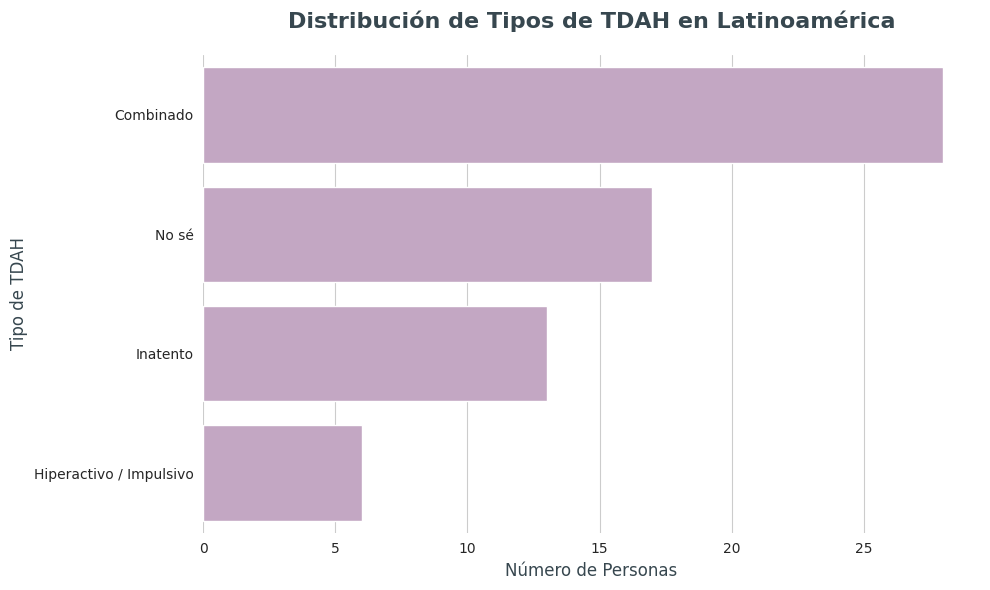

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset limpio
df = pd.read_csv('TDAH_LATAM_Limpio.csv', encoding='utf-8')

# Estilo y color
lila_principal = "#C8A2C8"
gris_oxford = "#37474F"

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Gráfica de barras para 'tipo_tdah'
ax = sns.countplot(y='tipo_tdah', data=df, color=lila_principal,
                   order=df['tipo_tdah'].value_counts().index)

# Títulos y etiquetas
plt.title('Distribución de Tipos de TDAH en Latinoamérica', fontsize=16, pad=20, color=gris_oxford, fontweight='bold')
plt.xlabel('Número de Personas', fontsize=12, color=gris_oxford)
plt.ylabel('Tipo de TDAH', fontsize=12, color=gris_oxford)

# Quitar bordes
sns.despine(left=True, bottom=True)

# Guardar la imagen
plt.tight_layout()
plt.savefig('distribucion_tdah_lila.png', dpi=300)
plt.show()